### Zadanie 1 (1p)
- Korzytając z pakietu <a href="https://github.com/JuliaMath/Polynomials.jl">Polynomials</a> zaimplementuj wielomiany Legendre'a zdefiniowane w taki sposób:

$P_{0}(x)=1$

$P_{1}(x)=x$

$P_{k+1}(x)=\frac{2k+1}{k+1} x P_{k}(x)-\frac{k}{k+1}P_{k-1}(x)$

- narysuj ich wykresy w przedziale (-1,1). 
- sprawdź(np. za pomocą fukcji <i>roots</i> z pakietu Polynomials), że ich zera  sa odciętymi punktów Gaussa. Test wykonaj dla wielomianow od 2 do 4 stopnia
- podaj związek tego faktu z podstawowym twierdzeniem kwadratur Gaussa (z wykładu)

In [3]:
using QuadGK, Polynomials, CSV, DataFrames, Plots, LinearAlgebra, SpecialPolynomials, Statistics

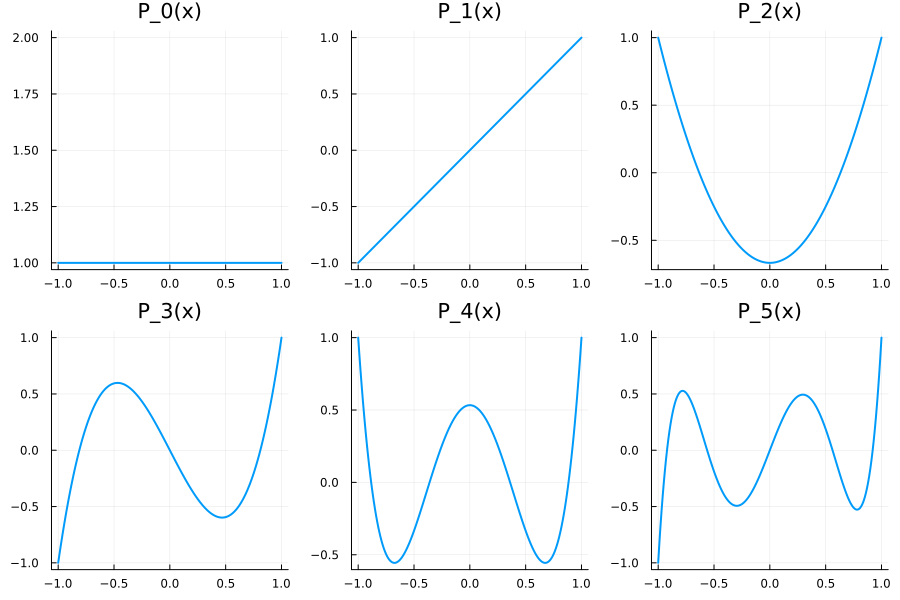

In [5]:
# Definicja wielomianów Legendre'a + wykresy w przedziale (-1,1)

function Legendre_Polynomial(n)
    if n == 0 
        return Polynomial([1])
    elseif n == 1
        return Polynomial([0, 1], :x)
    else
        P_prev = Legendre_Polynomial(n-1)
        P_prev_prev = Legendre_Polynomial(n-2)
        return ((2n+1)/(n+1))*Polynomial([0, 1], :x)*P_prev - ((n)/(n+1))*P_prev_prev
    end
end

plt = plot(layout = (2, 3), size=(900, 600))
x_vals = -1:0.01:1

for n in 0:5
    P = Legendre_Polynomial(n)
    plot!(plt, x_vals, P.(x_vals), subplot=n+1, title="P_$n(x)", label=false, linewidth=2)
end

display(plt)

In [11]:
# Sprawdzenie, że ich zera sa odciętymi punktów Gaussa (dla wielomianow od 2 do 4 stopnia).
for i in 1:4
    println("Gauss: ",gauss(Float64,i)[1])
    println("Legendre: ",sort(roots(Legendre_Polynomial(i))))
    println("------------------------------------------")
end

Gauss: [0.0]
Legendre: [0.0]
------------------------------------------
Gauss: [-0.5773502691896258, 0.5773502691896258]
Legendre: [-0.6324555320336759, 0.6324555320336758]
------------------------------------------
Gauss: [-0.7745966692414834, 0.0, 0.7745966692414834]
Legendre: [-0.8106434833777775, 0.0, 0.8106434833777775]
------------------------------------------
Gauss: [-0.8611363115940526, -0.3399810435848563, 0.3399810435848563, 0.8611363115940526]
Legendre: [-0.8837676634191414, -0.36064640328968045, 0.3606464032896807, 0.8837676634191414]
------------------------------------------


In [40]:
# Związek tego faktu z podstawowym twierdzeniem kwadratur Gaussa (z wykładu).
# Odcięte x_i n-punktowej kwadratury Gaussa z funkcją ważącą w(x)
# w [a, b] są zerami wielomianu ortogonalnego ϕ_n(x) dla tego
# samego przedziału i tej samej funkcji ważącej.

### Zadanie 2 (1p)
- Napisz funkcję, która dla podanej liczby punktów Gaussa $k$ oraz funkcji $f$  policzy $\int_{-1}^{1} f dx$
metodą używającą funkcji:
```julia
gauss(k)
```
oraz sumy 
```julia
sum(a .* f.(xp)) 
```
- przetestuj dla wielomianów coraz większych stopni (uwaga: dobrać takie współczynniki wielomianów, aby całka nie zerowała się w przedziale [-1.1])
- sprawdz kiedy przestaje być dokładna, 
- podaj związek z twierdzeniem o  stopniu dokładności kwadratury Gaussa 

In [41]:
# xp - odcięte punktów Gaussa, a - ich współczynniki
function integral(f, n)
    (xp, a) = gauss(Float64,n);
    return sum(a .* f.(xp)) 
end

# test
integral(Polynomial([1, 0, 1], :x), 2) # x^2 + 1

2.6666666666666665

In [42]:
# Testy dla wielomianów coraz większych stopni
test_polynomials = [Polynomial([1/3; zeros(i-1); 1]) for i in 1:9] # 1/3+x, 1/3+x^2, ...

quad_deg = 3

for (i,poly) in enumerate(test_polynomials)
    pn = Polynomial(poly)
    poly_deg = i
    gauss = integral(pn, quad_deg)    
    println("Degree ", poly_deg, ": ", pn, "  Gauss=", round(gauss, digits=6), " Exact result=", quadgk(poly,-1,1))
end

## już dla stopnia 6 przestaje być dokładna dla 3 punktów Gaussa, dla 2 punktów był to 4 stopień

Degree 1: 0.333333 + 1.0*x  Gauss=0.666667 Exact result=(0.6666666666666665, 0.0)
Degree 2: 0.333333 + 1.0*x^2  Gauss=1.333333 Exact result=(1.3333333333333335, 2.220446049250313e-16)
Degree 3: 0.333333 + 1.0*x^3  Gauss=0.666667 Exact result=(0.6666666666666666, 1.1102230246251565e-16)
Degree 4: 0.333333 + 1.0*x^4  Gauss=1.066667 Exact result=(1.0666666666666667, 2.220446049250313e-16)
Degree 5: 0.333333 + 1.0*x^5  Gauss=0.666667 Exact result=(0.6666666666666666, 1.1102230246251565e-16)
Degree 6: 0.333333 + 1.0*x^6  Gauss=0.906667 Exact result=(0.9523809523809522, 1.1102230246251565e-16)
Degree 7: 0.333333 + 1.0*x^7  Gauss=0.666667 Exact result=(0.6666666666666665, 0.0)
Degree 8: 0.333333 + 1.0*x^8  Gauss=0.810667 Exact result=(0.8888888888888887, 1.1102230246251565e-16)
Degree 9: 0.333333 + 1.0*x^9  Gauss=0.666667 Exact result=(0.6666666666666665, 0.0)


In [43]:
# Związek z twierdzeniem o stopniu dokładności kwadratury Gaussa
# Kwadratura ma stopień dokładności 2n − 1 (dla n-punktowej kwadratury) 
# Czyli dla 2-puntkowej mamy 3 stopień, dla 3-punktowej mamy 5 stopień itd..., co się zgadza z powyższymi obliczeniami.

### Zadanie 3 (1p)
  
Skorzystaj z rozwiązania zadania 2 do napisania funkcji 
liczącej  całki w dowolnym przedziale $\int_{a}^{b} f(x) dx$ 

dokonując normalizacji  do $\int_{-1}^{1} F(z) dz$ 

podstawiając:

$x=\frac{b+a}{2}+ \frac{b-a}{2} z $ oraz 

$dx =\frac{b-a}{2} dz $

Przetestuj działanie na kilku przykładach i sprawdź z wynikami otrzymanymi analitycznie.


In [46]:
function integral_v2(f, n, a, b)
    (xp, w) = gauss(Float64,n);
    x_new = (b+a)/2 .+ (b-a)/2 .* xp
    w_new = w .* (b-a)/2
    return sum(w_new .* f.(x_new))
end

# test
integral_v2(Polynomial([1, 0, 1], :x), 2, -1, 1) # x^2 + 1

2.6666666666666665

In [50]:
# Przykład 1: - x^4 + 1/2 na przedziale [-1,1], wynik to: 1,4
println("Wartość obliczona analitycznie: ", 1.4)
for i in 1:10
    println("dla ",i," pkt kwadratury : ", integral_v2(x -> x^4 + 1/2, i, -1, 1))
end

Wartość obliczona analitycznie: 1.4
dla 1 pkt kwadratury : 1.0
dla 2 pkt kwadratury : 1.222222222222222
dla 3 pkt kwadratury : 1.4
dla 4 pkt kwadratury : 1.4000000000000001
dla 5 pkt kwadratury : 1.4
dla 6 pkt kwadratury : 1.4
dla 7 pkt kwadratury : 1.4000000000000001
dla 8 pkt kwadratury : 1.4000000000000001
dla 9 pkt kwadratury : 1.4000000000000001
dla 10 pkt kwadratury : 1.4000000000000008


In [51]:
# Przykład 2: + x^7 na przedziale [1,3], wynik to: 822
println("Wartość obliczona analitycznie: ", 822)
for i in 1:10
    println("dla ",i," pkt kwadratury : ", integral_v2(x -> x^7 + 1, i, 1, 3))
end

Wartość obliczona analitycznie: 882
dla 1 pkt kwadratury : 258.0
dla 2 pkt kwadratury : 769.2592592592591
dla 3 pkt kwadratury : 821.36
dla 4 pkt kwadratury : 822.0000000000002
dla 5 pkt kwadratury : 821.9999999999999
dla 6 pkt kwadratury : 822.0000000000002
dla 7 pkt kwadratury : 822.0000000000002
dla 8 pkt kwadratury : 822.0000000000003
dla 9 pkt kwadratury : 822.0000000000002
dla 10 pkt kwadratury : 822.0000000000001


### Zadanie 4 (1p)
Głowną funkcją pakietu QuadGK jest adaptacyjna funkcja <a href="https://juliamath.github.io/QuadGK.jl/stable/#QuadGK.quadgk"> guadgk</a> używająca całkowania  Gauss-Kronroda

- użyj tej funkcji do policzenia  całki dla przykładowego wielomianu.
- funkcja ta ma możliwość liczenia również całek do nieskończoności.


 Policz całkę od minus do plus nieskonczonosci 
 standardowego rozkładu normalnego Gaussa
$ \frac{1}{\sqrt{2\pi}}exp(\frac{-x^2}{2})$

In [54]:
# Przykład: + x^7 na przedziale [1,3], wynik to: 822
println("Wartość obliczona analitycznie: ", 822)
println("Wartość z pakietu QuadGK: ", quadgk(x -> x^7 + 1, 1, 3))

Wartość obliczona analitycznie: 822
Wartość z pakietu QuadGK: (822.0000000000002, 2.2737367544323206e-13)


In [55]:
# Policz całkę od minus do plus nieskonczonosci standardowego rozkładu normalnego Gaussa 
println("Wartość z pakietu QuadGK: ", quadgk(x -> 1/sqrt(2*pi)*exp(-x^2/2), -Inf, +Inf))

Wartość z pakietu QuadGK: (1.0000000000032583, 1.4395584886006938e-8)


### Zadanie 5 (3p)
Napisz własne funkcje całkujące -  w wybranym przedziale (a,b) - złożonymi metodami prostokątów, trapezów oraz Simpsona. Dla stałego przedziału zwiększaj liczbę użytych punktów (n). Narysuj wykresy funkcji błędu  w stosunku do wyniku otrzymanego analitycznie, 
w zależnosci od $h=\frac{b-a}{n}$:
1. wykładniczej
2. trygonometrycznej (np. sin (x) w przedziale $[0,2\pi]$)


In [72]:
function rect_integration(f, n, a, b)
    h = (b - a) / n
    value = 0.0
    for i in 1:n
        x_mid = a + (i - 0.5) * h  # punkt środkowy przedziału
        value += f(x_mid) * h
    end
    return value
end

function trapezoid_integration(f, n, a, b)
    h = (b - a) / n
    value = (f(a) + f(b)) / 2  # połowa wartości na końcach przedziału
    for i in 1:n-1
        x = a + i * h
        value += f(x)  # pełne wartości w punktach wewnętrznych
    end
    return value * h
end

function simpson_integration(f, n, a, b)
    if n % 2 != 0
        n += 1  # zapewniamy parzystą liczbę przedziałów
        println("Dostosowano liczbę przedziałów do $n dla metody Simpsona.")
    end
    
    h = (b - a) / n
    value = f(a) + f(b)  # wartości na końcach przedziału
    
    for i in 1:2:n-1
        x = a + i * h
        value += 4 * f(x)  # wartości z wagą 4 (punkty nieparzyste)
    end
    
    for i in 2:2:n-2
        x = a + i * h
        value += 2 * f(x)  # wartości z wagą 2 (punkty parzyste)
    end
    
    return value * h / 3
end

simpson_integration (generic function with 1 method)

In [89]:
# Funkcje do testowania
f_exp(x) = 2^x              # całka z 2^x od 0 do 1 to 1/ln(2)
f_sin(x) = sin(x)           # całka z sin(x) od 0 do pi to 2

# Przedziały
a_exp, b_exp = 0.0, 1.0
a_sin, b_sin = 0.0, pi

# Analityczne wyniki
exact_exp = 1/log(2)
exact_sin = 2.0

# Liczba punktów
ns = 2 .^ (2:10)  # 4, 8, 16, ..., 1024

# Funkcja błędu
function compute_errors(f, exact, a, b)
    rect_errs = Float64[]
    trap_errs = Float64[]
    simp_errs = Float64[]
    for n in ns
        push!(rect_errs, abs(rect_integration(f, n, a, b) - exact))
        push!(trap_errs, abs(trapezoid_integration(f, n, a, b) - exact))
        push!(simp_errs, abs(Simpson_integration(f, n + n % 2, a, b) - exact))  # poprawka dla nieparzystych n
    end
    return rect_errs, trap_errs, simp_errs
end

# Obliczanie błędów
err_exp = compute_errors(f_exp, exact_exp, a_exp, b_exp)
err_sin = compute_errors(f_sin, exact_sin, a_sin, b_sin)

([0.05234430595406181, 0.012909085599127845, 0.0032163781679499515, 0.0008034163099304159, 0.0002008117283676114, 5.020028590330128e-5, 1.2549906099224017e-5, 3.137466188629645e-6, 7.843658997863656e-7], [0.1038811020629602, 0.025768398054449193, 0.006429656227660452, 0.0016066390298559163, 0.00040161135996252817, 0.00010039981579623714, 2.5099764946912018e-5, 6.274929423177866e-6, 1.5687316166079768e-6], [0.0045597549844207386, 0.0002691699483881038, 1.6591047935499148e-5, 1.0333694127062643e-6, 6.453000134243325e-8, 4.032257638897363e-9, 2.520033071107264e-10, 1.575317654101127e-11, 9.809930645587883e-13])

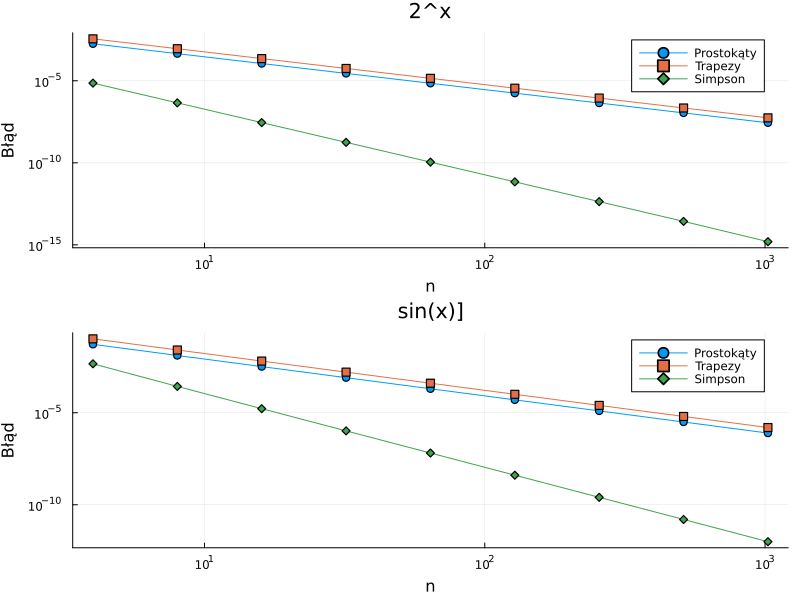

In [95]:
# Wykresy
p1 = plot(ns, err_exp[1], label="Prostokąty", xscale=:log10, yscale=:log10, marker=:circle, title="2^x")
plot!(ns, err_exp[2], label="Trapezy", marker=:square)
plot!(ns, err_exp[3], label="Simpson", marker=:diamond)
xlabel!("n")
ylabel!("Błąd")

p2 = plot(ns, err_sin[1], label="Prostokąty", xscale=:log10, yscale=:log10, marker=:circle, title="sin(x)]")
plot!(ns, err_sin[2], label="Trapezy", marker=:square)
plot!(ns, err_sin[3], label="Simpson", marker=:diamond)
xlabel!("n")
ylabel!("Błąd")

plot(p1, p2, layout=(2,1), size=(800,600))